In [320]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv

# ==========================================================
# COSTANTI FISICHE
# ==========================================================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

# ==========================================================
# FILE INPUT
# ==========================================================
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"


In [321]:
# ==========================================================
# PARAMETRI SS
# ==========================================================
eta = 0.083
Nr = 400
Nnu = 120
nu_min = 1e13
nu_max = 1e17

In [322]:
# ==========================================================
# ADAF 
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
ADAF_BETA_DEFAULT = 0.5

C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

def bessk(n, x):
    return kv(n, x)

def g(teta):
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # Heating
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # Synchrotron
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    # Compton
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    # Brems
    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    # Equazioni
    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]

def spectrum_adaf(te, f, xm, m, mdot, beta):

    numin = 1e10
    numax = 1e17                                                 #CAMBIARE QUI !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    num = 400

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        # SYNCHROTRON
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = 0.0

        # COMPTON
        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = 0.0

        # BREMS
        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    # questo y è log10(nu * Lnu)
    flux = 10**lls + 10**llc + 10**llb
    y = lnu + np.log10(flux)

    return lnu, y

def specdata(m, mdot, beta, verbose=False):

    if verbose:
        print(f"ADAF -> m={m}, mdot={mdot}, beta={beta}")

    y0 = [0.5, 1.0, 0.99]
    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        print(f"Non converge per mdot={mdot}")

    y = sol.x

    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum_adaf(te, f, xm, m, mdot, beta)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu

    return nu, Lnu, log_nuLnu

In [323]:
# ==========================================================
# PARAMETRI MCMC
# ==========================================================
N_STEPS = 25000
BURN_IN = 5000

# ampiezze proposal in log10(m), log10(mdot)
#STEP_LOGM = 0.08
#STEP_LOGMDOT = 0.08

STEP_LOGM = 0.20
STEP_LOGMDOT = 0.20

# covering factor globale fisso
CF_BLR = 0.1

# errore relativo sulle linee osservate
# sigma_i = REL_ERR * L_line_i
REL_ERR = 0.20

# prior uniformi nei limiti seguenti
LOGM_MIN, LOGM_MAX = 7.0, 10.5
LOGMDOT_MIN, LOGMDOT_MAX = -5.0, -0.3


In [324]:
# ==========================================================
# FUNZIONI UTILI
# ==========================================================
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(row, norm_columns):
    risultati = []

    for col in norm_columns:
        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line_obs": L_line
        })

    return pd.DataFrame(risultati)

In [325]:
# ==========================================================
# SPETTRO SS
# ==========================================================
def costruisci_spettro_ss(MBH_solar, mdot_edd, eta=0.083, Nr=2000, Nnu=400,
                          nu_min=1e13, nu_max=1e17):
    """
    MBH_solar : massa in Msun
    mdot_edd  : tasso di accrescimento in unita' di Eddington
    """
    MBH = MBH_solar * Msun
    Ledd = 1.3e38 * MBH_solar
    Ldisk = mdot_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = {
        "MBH_solar": MBH_solar,
        "mdot_edd": mdot_edd,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot_cgs": Mdot
    }

    return nu, Lnu, nuLnu, info

In [326]:
# ==========================================================
# SPETTRO ADAF
# ==========================================================
def costruisci_spettro_adaf(m, mdot, beta=ADAF_BETA_DEFAULT, verbose=False):
    """
    Compatibile con la tua specdata attuale che restituisce:
        (nu, Lnu, log_nuLnu)
    oppure con eventuale dict.
    """
    risultato = specdata(
        m=m,
        mdot=mdot,
        beta=beta,
        verbose=verbose
    )

    # Caso dict
    if isinstance(risultato, dict):
        # provo prima il formato dict "classico"
        if "lnu" in risultato and "log_nuFnu" in risultato:
            lnu = np.asarray(risultato["lnu"], dtype=float)
            log_nuLnu = np.asarray(risultato["log_nuFnu"], dtype=float)

            nu = 10**lnu
            nuLnu = 10**log_nuLnu
            Lnu = nuLnu / nu

        elif "nu" in risultato and "Lnu" in risultato:
            nu = np.asarray(risultato["nu"], dtype=float)
            Lnu = np.asarray(risultato["Lnu"], dtype=float)
            nuLnu = nu * Lnu

        else:
            raise TypeError("Formato dict di specdata non riconosciuto")

        info = {
            "m": m,
            "mdot": mdot,
            "beta": beta,
            "te": risultato.get("te", np.nan),
            "xm": risultato.get("xm", np.nan),
            "f": risultato.get("f", np.nan)
        }

    # Caso tuple
    elif isinstance(risultato, tuple):
        if len(risultato) == 3:
            # tuo formato attuale: (nu, Lnu, log_nuLnu)
            nu = np.asarray(risultato[0], dtype=float)
            Lnu = np.asarray(risultato[1], dtype=float)
            log_nuLnu = np.asarray(risultato[2], dtype=float)

            # ricostruisco nuLnu in modo coerente
            nuLnu = nu * Lnu

        elif len(risultato) >= 2:
            # fallback: assumo (nu, Lnu, ...)
            nu = np.asarray(risultato[0], dtype=float)
            Lnu = np.asarray(risultato[1], dtype=float)
            nuLnu = nu * Lnu

        else:
            raise TypeError("Formato tuple di specdata non riconosciuto")

        info = {
            "m": m,
            "mdot": mdot,
            "beta": beta,
            "te": np.nan,
            "xm": np.nan,
            "f": np.nan
        }

    else:
        raise TypeError("specdata ha restituito un formato non riconosciuto")

    # filtro numerico
    mask = np.isfinite(nu) & np.isfinite(Lnu) & np.isfinite(nuLnu) & (nu > 0) & (Lnu >= 0)
    nu = nu[mask]
    Lnu = Lnu[mask]
    nuLnu = nuLnu[mask]

    if len(nu) < 2:
        raise RuntimeError("Spettro ADAF non valido dopo filtering")

    idx = np.argsort(nu)
    nu = nu[idx]
    Lnu = Lnu[idx]
    nuLnu = nuLnu[idx]

    return nu, Lnu, nuLnu, info

In [327]:
# ==========================================================
# CALCOLO L_ION
# ==========================================================
def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=None):
    risultati = []

    if nu_max is None:
        nu_max = np.max(nu)

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        nu_ion = row["nu_ion"]
        E_ion = row["E_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)

In [328]:
# ==========================================================
# COSTRUZIONE DEL MODELLO DI RIGA
# ==========================================================
def predici_linee_da_modello(logm, logmdot, regime, df_trans, cf_blr=0.1, beta_adaf=0.5):
    """
    Restituisce un dataframe con:
        line_name, L_ion, L_line_mod
    """
    m = 10**logm
    mdot = 10**logmdot

    if regime.upper() == "SS":
        nu, Lnu, nuLnu, info = costruisci_spettro_ss(
            MBH_solar=m,
            mdot_edd=mdot,
            eta=eta,
            Nr=Nr,
            Nnu=Nnu,
            nu_min=nu_min,
            nu_max=nu_max
        )
    elif regime.upper() == "ADAF":
        nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
            m=m,
            mdot=mdot,
            beta=beta_adaf,
            verbose=False
        )
    else:
        raise ValueError("regime deve essere 'SS' oppure 'ADAF'")

    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=np.max(nu))
    df_lion["L_line_mod"] = cf_blr * df_lion["L_ion"]

    return df_lion

In [329]:
# ==========================================================
# PREPARAZIONE DATI OSSERVATI PER UN SINGOLO BLAZAR
# ==========================================================
def prepara_dati_blazar(label_target, file_linee, file_transizioni):
    df_tab = pd.read_csv(file_linee)
    df_trans = leggi_transizioni(file_transizioni)

    col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
    norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

    df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()
    df_all["label"] = df_all["label"].astype(str).str.strip()

    label_target_clean = str(label_target).strip()

    # 1) provo match esatto
    df_match = df_all[df_all["label"] == label_target_clean].copy()

    # 2) se non trova nulla, provo match parziale case-insensitive
    if df_match.empty:
        df_match = df_all[
            df_all["label"].str.contains(label_target_clean, case=False, na=False)
        ].copy()

    # 3) gestione errori chiara
    if df_match.empty:
        print("Label disponibili:")
        print(df_all["label"].drop_duplicates().sort_values().tolist())
        raise ValueError(f"Nessun blazar trovato per label_target = '{label_target}'")

    if len(df_match) > 1:
        print("Trovati più blazar compatibili:")
        print(df_match["label"].tolist())
        print("Uso il primo della lista.")

    row = df_match.iloc[0]

    df_obs = estrai_linee_osservate(row, norm_columns)

    df_obs = df_obs.merge(
        df_trans[["line_name", "E_ion", "nu_ion"]],
        on="line_name",
        how="left"
    )

    df_obs["sigma_L"] = REL_ERR * df_obs["L_line_obs"]

    print(f"Blazar selezionato: {row['label']}")
    print(f"Numero linee osservate usate: {len(df_obs)}")

    return df_all, df_trans, df_obs

In [330]:
# ==========================================================
# LOG-PRIOR
# ==========================================================
def log_prior(theta, regime="SS"):
    logm, logmdot = theta

    if not (7.0 < logm < 10.5):
        return -np.inf

    if regime.upper() == "ADAF":
        # ADAF: mdot < 1e-2
        if not (-5.0 < logmdot < -2.0):
            return -np.inf

    elif regime.upper() == "SS":
        # disco standard: mdot > 1e-2
        if not (-2.0 < logmdot < 0.0):
            return -np.inf

    else:
        return -np.inf

    return 0.0

In [331]:
# ==========================================================
# LOG-LIKELIHOOD
# ==========================================================
def log_likelihood(theta, df_obs, df_trans, regime, cf_blr=0.1, beta_adaf=0.5):
    logm, logmdot = theta

    try:
        df_mod = predici_linee_da_modello(
            logm=logm,
            logmdot=logmdot,
            regime=regime,
            df_trans=df_trans,
            cf_blr=cf_blr,
            beta_adaf=beta_adaf
        )
    except Exception:
        return -np.inf

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    df_cmp = df_cmp[
        df_cmp["L_line_obs"].notna() &
        df_cmp["sigma_L"].notna() &
        df_cmp["L_line_mod"].notna() &
        np.isfinite(df_cmp["L_line_mod"]) &
        (df_cmp["L_line_mod"] >= 0) &
        (df_cmp["sigma_L"] > 0)
    ].copy()

    if len(df_cmp) == 0:
        return -np.inf

    resid = df_cmp["L_line_obs"].values - df_cmp["L_line_mod"].values
    sigma = df_cmp["sigma_L"].values

    if not np.all(np.isfinite(resid)) or not np.all(np.isfinite(sigma)):
        return -np.inf

    return -0.5 * np.sum((resid / sigma)**2 + np.log(2*np.pi*sigma**2))

In [332]:
# ==========================================================
# LOG-POSTERIOR
# ==========================================================
def log_posterior(theta, df_obs, df_trans, regime, cf_blr=0.1, beta_adaf=0.5):
    lp = log_prior(theta, regime=regime)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(
        theta=theta,
        df_obs=df_obs,
        df_trans=df_trans,
        regime=regime,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf
    )

    if not np.isfinite(ll):
        return -np.inf

    return lp + ll

In [333]:
# ==========================================================
# METROPOLIS-HASTINGS MCMC
# ==========================================================
def run_mcmc(
    theta0,
    n_steps,
    df_obs,
    df_trans,
    regime,
    cf_blr=0.1,
    beta_adaf=0.5,
    step_logm=0.08,
    step_logmdot=0.08,
    random_seed=42
):
    rng = np.random.default_rng(random_seed)

    chain = np.zeros((n_steps, 2))
    logpost_chain = np.zeros(n_steps)

    theta_current = np.array(theta0, dtype=float)
    logp_current = log_posterior(
        theta_current, df_obs, df_trans, regime,
        cf_blr=cf_blr, beta_adaf=beta_adaf
    )

    accept = 0

    for i in range(n_steps):
        proposal = theta_current + np.array([
            rng.normal(0, step_logm),
            rng.normal(0, step_logmdot)
        ])

        logp_proposal = log_posterior(
            proposal, df_obs, df_trans, regime,
            cf_blr=cf_blr, beta_adaf=beta_adaf
        )

        if np.log(rng.uniform()) < (logp_proposal - logp_current):
            theta_current = proposal
            logp_current = logp_proposal
            accept += 1

        chain[i] = theta_current
        logpost_chain[i] = logp_current

    acc_frac = accept / n_steps

    return {
        "chain": chain,
        "logpost": logpost_chain,
        "acceptance_fraction": acc_frac
    }

In [334]:
# ==========================================================
# RIASSUNTO CAMPIONE POSTERIORE
# ==========================================================
def riassumi_catena(chain, burn_in=0):
    samp = chain[burn_in:]

    logm = samp[:, 0]
    logmdot = samp[:, 1]

    out = {
        "logm_median": np.median(logm),
        "logm_p16": np.percentile(logm, 16),
        "logm_p84": np.percentile(logm, 84),
        "logmdot_median": np.median(logmdot),
        "logmdot_p16": np.percentile(logmdot, 16),
        "logmdot_p84": np.percentile(logmdot, 84),
    }

    out["m_median"] = 10**out["logm_median"]
    out["mdot_median"] = 10**out["logmdot_median"]

    return out

In [335]:
# ==========================================================
# GRAFICI DIAGNOSTICI DELLA CATENA
# ==========================================================
def plot_trace(chain, burn_in=0, titolo=""):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(chain[:, 0], lw=0.7)
    axes[0].axvline(burn_in, color="red", linestyle="--")
    axes[0].set_ylabel(r"$\log_{10}(m)$")

    axes[1].plot(chain[:, 1], lw=0.7)
    axes[1].axvline(burn_in, color="red", linestyle="--")
    axes[1].set_ylabel(r"$\log_{10}(\dot m)$")
    axes[1].set_xlabel("Step")

    fig.suptitle(titolo)
    plt.tight_layout()
    plt.show()


def plot_corner_like(chain, burn_in=0, titolo=""):
    samp = chain[burn_in:]
    x = samp[:, 0]
    y = samp[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].hist(x, bins=40, color="lightgray", edgecolor="black")
    axes[0].set_xlabel(r"$\log_{10}(m)$")

    axes[1].hist(y, bins=40, color="lightgray", edgecolor="black")
    axes[1].set_xlabel(r"$\log_{10}(\dot m)$")

    axes[2].scatter(x, y, s=4, alpha=0.25)
    axes[2].set_xlabel(r"$\log_{10}(m)$")
    axes[2].set_ylabel(r"$\log_{10}(\dot m)$")

    fig.suptitle(titolo)
    plt.tight_layout()
    plt.show()

In [336]:
# ==========================================================
# CONFRONTO DATI OSSERVATI VS MODELLO BEST-FIT
# ==========================================================
def plot_best_fit_linee(df_obs, df_trans, best_logm, best_logmdot, regime, cf_blr=0.1, beta_adaf=0.5):
    df_mod = predici_linee_da_modello(
        logm=best_logm,
        logmdot=best_logmdot,
        regime=regime,
        df_trans=df_trans,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf
    )

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    ordine_linee = ["CIII", "CIV", "MgII", "Hb", "Hg", "Hd", "Ha"]
    linee_presenti = df_cmp["line_name"].tolist()
    linee_ordinate = [l for l in ordine_linee if l in linee_presenti]
    linee_ordinate += [l for l in linee_presenti if l not in linee_ordinate]

    x = np.arange(len(linee_ordinate))

    y_obs = []
    y_err = []
    y_mod = []

    for linea in linee_ordinate:
        row = df_cmp[df_cmp["line_name"] == linea].iloc[0]
        y_obs.append(row["L_line_obs"])
        y_err.append(row["sigma_L"])
        y_mod.append(row["L_line_mod"])

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.errorbar(
        x, y_obs, yerr=y_err,
        fmt="o", markersize=7, capsize=3,
        color="black", label="Osservato"
    )

    ax.scatter(
        x, y_mod,
        s=80,
        marker="s",
        label=f"Modello {regime}"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(linee_ordinate)
    ax.set_yscale("log")
    ax.set_ylabel(r"$L_{\rm line}$ [erg s$^{-1}$]")
    ax.set_xlabel("Linea")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [337]:
# ==========================================================
# FUNZIONE ALTA-LEVEL: FIT DI UN BLAZAR
# ==========================================================
def fit_blazar_mcmc(
    label_target,
    regime="SS",
    theta0=(9.0, -2.0),
    n_steps=25000,
    burn_in=5000,
    cf_blr=0.1,
    beta_adaf=0.5,
    random_seed=42
):
    df_all, df_trans, df_obs = prepara_dati_blazar(
        label_target=label_target,
        file_linee=file_linee,
        file_transizioni=file_transizioni
    )

    risultato = run_mcmc(
        theta0=theta0,
        n_steps=n_steps,
        df_obs=df_obs,
        df_trans=df_trans,
        regime=regime,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf,
        step_logm=STEP_LOGM,
        step_logmdot=STEP_LOGMDOT,
        random_seed=random_seed
    )

    chain = risultato["chain"]
    acc_frac = risultato["acceptance_fraction"]

    summary = riassumi_catena(chain, burn_in=burn_in)

    print("=" * 80)
    print(f"Blazar: {label_target}")
    print(f"Regime: {regime}")
    print(f"Acceptance fraction = {acc_frac:.3f}")
    print(f"log10(m)    = {summary['logm_median']:.3f} "
          f"[{summary['logm_p16']:.3f}, {summary['logm_p84']:.3f}]")
    print(f"log10(mdot) = {summary['logmdot_median']:.3f} "
          f"[{summary['logmdot_p16']:.3f}, {summary['logmdot_p84']:.3f}]")
    print(f"m_median    = {summary['m_median']:.3e} Msun")
    print(f"mdot_median = {summary['mdot_median']:.3e}")
    print("=" * 80)

    plot_trace(chain, burn_in=burn_in, titolo=f"{label_target} - {regime} - trace")
    plot_corner_like(chain, burn_in=burn_in, titolo=f"{label_target} - {regime} - posteriori")

    plot_best_fit_linee(
        df_obs=df_obs,
        df_trans=df_trans,
        best_logm=summary["logm_median"],
        best_logmdot=summary["logmdot_median"],
        regime=regime,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf
    )

    return {
        "df_obs": df_obs,
        "chain": chain,
        "summary": summary,
        "acceptance_fraction": acc_frac
    }

In [338]:
nu, Lnu, nuLnu, info = costruisci_spettro_adaf(1e9, 5e-4, beta=0.5, verbose=False)
print(len(nu), np.min(nu), np.max(nu))
print(np.all(np.isfinite(nu)), np.all(np.isfinite(Lnu)))

df_all, df_trans, df_obs = prepara_dati_blazar("J1816", file_linee, file_transizioni)
print(log_likelihood((9.0, -3.0), df_obs, df_trans, regime="ADAF", cf_blr=0.1, beta_adaf=0.5))

400 10000000000.0 1e+17
True True
Blazar selezionato: J1816.9-4944
Numero linee osservate usate: 3
-336.2507097498616


In [339]:
test = specdata(1e9, 5e-4, 0.5, verbose=False)

print(type(test))
if isinstance(test, tuple):
    print("lunghezza tupla =", len(test))
    for i, x in enumerate(test):
        arr = np.asarray(x)
        print(i, arr.shape, arr[:5] if arr.ndim > 0 else arr)
elif isinstance(test, dict):
    print(test.keys())
    for k, v in test.items():
        arr = np.asarray(v)
        if arr.ndim > 0:
            print(k, arr.shape, arr[:5])
        else:
            print(k, arr)

<class 'tuple'>
lunghezza tupla = 3
0 (400,) [1.00000000e+10 1.04122326e+10 1.08414587e+10 1.12883789e+10
 1.17537227e+10]
1 (400,) [5.92632535e+27 6.02286368e+27 6.12097460e+27 6.22068373e+27
 6.32201708e+27]
2 (400,) [37.77278549 37.79734689 37.8219083  37.8464697  37.8710311 ]


In [340]:
nu, Lnu, nuLnu, info = costruisci_spettro_adaf(1e9, 5e-4, beta=0.5, verbose=False)
print(len(nu), np.min(nu), np.max(nu))
print(np.all(np.isfinite(nu)), np.all(np.isfinite(Lnu)), np.all(np.isfinite(nuLnu)))

400 10000000000.0 1e+17
True True True


In [341]:
df_all, df_trans, df_obs = prepara_dati_blazar("J1816", file_linee, file_transizioni)

print(log_likelihood(
    (9.0, -3.0),
    df_obs,
    df_trans,
    regime="ADAF",
    cf_blr=0.1,
    beta_adaf=0.5
))

Blazar selezionato: J1816.9-4944
Numero linee osservate usate: 3
-336.2507097498616


Blazar selezionato: J0021.6-6835
Numero linee osservate usate: 3
Blazar: J0021
Regime: SS
Acceptance fraction = 0.085
log10(m)    = 7.072 [7.027, 7.137]
log10(mdot) = -1.929 [-1.974, -1.866]
m_median    = 1.179e+07 Msun
mdot_median = 1.177e-02


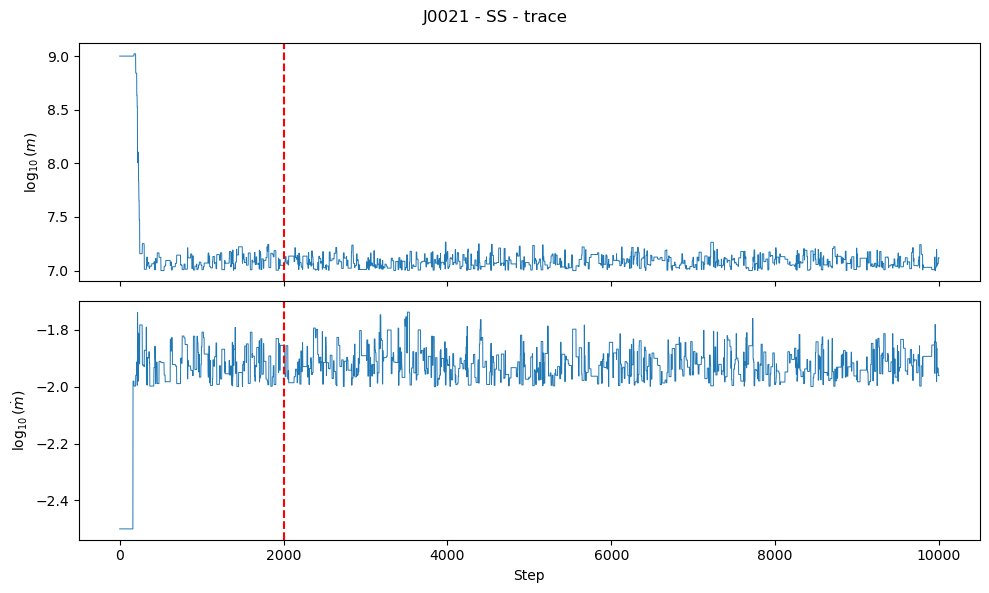

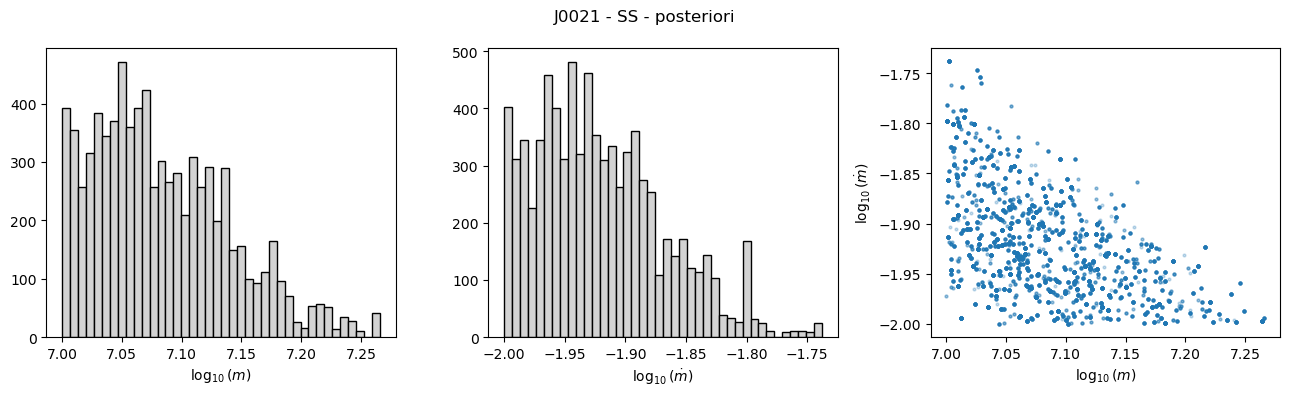

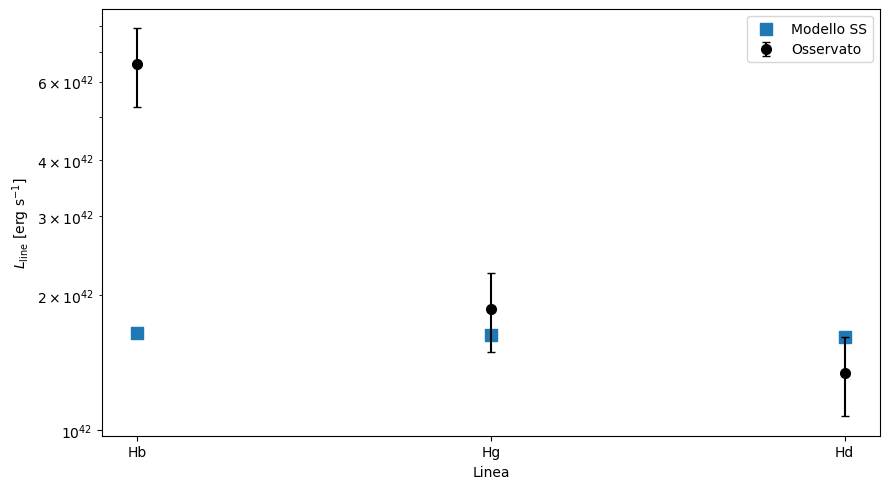

In [345]:
"""
ris_ss = fit_blazar_mcmc(
    label_target="J0922",
    regime="SS",
    theta0=(9.0, -2.0),
    n_steps=3000,
    burn_in=500,
    cf_blr=0.1
)
"""
ris_ss = fit_blazar_mcmc(
    label_target="J0021",
    regime="SS",
    theta0=(9.0, -2.5),
    n_steps=10000,
    burn_in=2000,
    cf_blr=0.1
)

Blazar selezionato: J0021.6-6835
Numero linee osservate usate: 3
Blazar: J0021
Regime: ADAF
Acceptance fraction = 0.157
log10(m)    = 9.874 [9.579, 10.285]
log10(mdot) = -2.287 [-2.492, -2.108]
m_median    = 7.490e+09 Msun
mdot_median = 5.165e-03


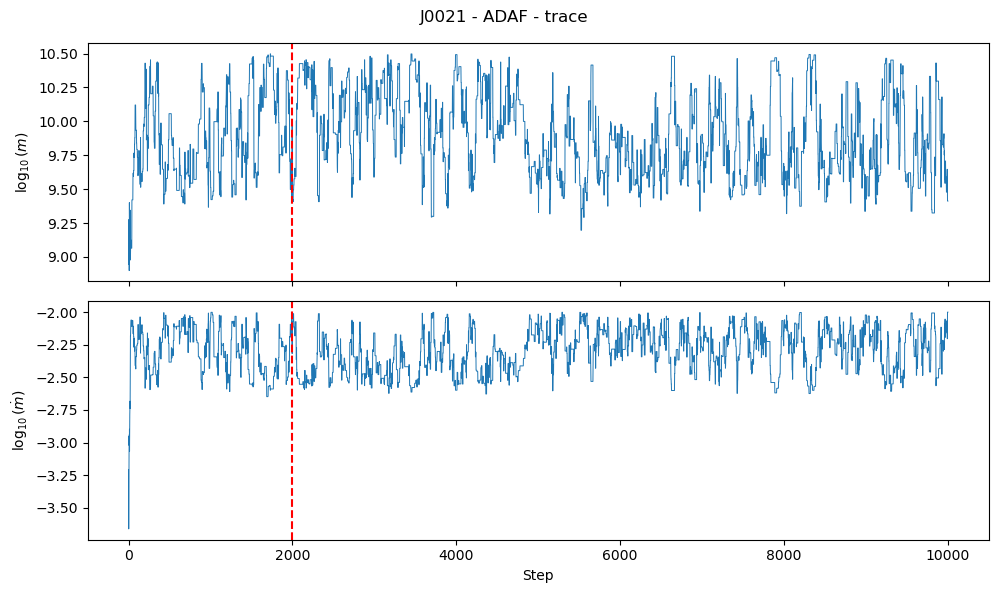

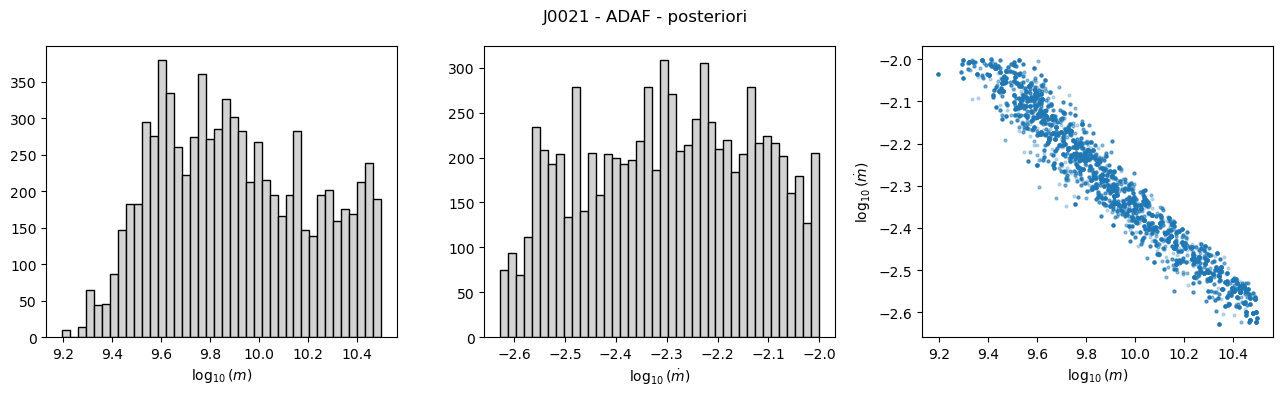

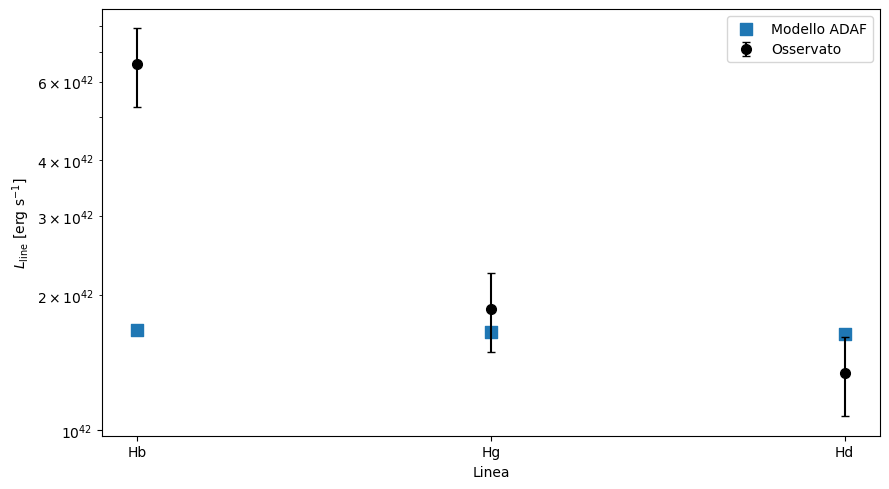

In [346]:
"""
ris_adaf = fit_blazar_mcmc(
    label_target="J0922",
    regime="ADAF",
    theta0=(9.0, -3.0),
    n_steps=3000,
    burn_in=500,
    cf_blr=0.1,
    beta_adaf=0.5
)
"""
ris_adaf = fit_blazar_mcmc(
    label_target="J0021",
    regime="ADAF",
    theta0=(9.0, -3.0),
    n_steps=10000,
    burn_in=2000,
    cf_blr=0.1,
    beta_adaf=0.5
)